# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anasYaha/Flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question** : peut-on classer les requetes de recherche par risque de cannibalisation
(trafic fragmente entre plusieurs pages du meme client) de facon plus utile qu'une
heuristique simple (volume x nombre de pages concurrentes) ?

**Decision supportee** : quelles requetes une equipe contenu doit revoir en priorite pour
merger, rediriger ou consolider des pages concurrentes -- une ressource limitee (temps humain)
a allouer sur un nombre limite de cas par cycle.


In [5]:
print('Question: quelles queries prioriser pour une revue merge/redirect,',      'et un modele appris bat-il une heuristique simple sur cette priorisation ?')


Question: quelles queries prioriser pour une revue merge/redirect, et un modele appris bat-il une heuristique simple sur cette priorisation ?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- Source : `FlyRank/internship-warehouse` (Hugging Face, acces gate par token, lecture seule).
- Tables : `fact_content_query_90d` (fenetre glissante 90 jours) jointe a
  `fact_content_daily_performance` (mois 2026-03) pour ne garder que le contenu actif en mars.
- Grain : (client_hash_id, query_hash_id) -- une ligne par requete par client, agregee depuis
  les lignes (client, query, content).
- Exclusions : aucun nom de client, domaine ou requete brute -- uniquement des hash ids et
  features agregees. Les requetes a page unique restent dans le denominateur (jamais
  cannibalisables par construction, mais pas retirees pour ne pas biaiser le taux de base).
- Echantillon final : **1 129 695** paires (client, query) sur **43 clients**.


In [4]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

import os, getpass, duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'fact_daily_mar': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
QUERY_ID_COL = 'query_hash_id'

cannib = con.sql(f"""
    WITH per_query AS (
        SELECT client_hash_id, {QUERY_ID_COL} AS query_id, content_hash_id,
               ANY_VALUE(content_visible_query_count)  AS content_visible_query_count,
               ANY_VALUE(rare_impressions_share)        AS rare_impressions_share,
               ANY_VALUE(anonymized_impressions_share)  AS anonymized_impressions_share,
               SUM(impressions_90d)                     AS content_impressions_for_query
        FROM {TABLES['fact_query_90d']}
        WHERE content_hash_id IN (SELECT DISTINCT content_hash_id FROM {TABLES['fact_daily_mar']})
        GROUP BY 1, 2, 3
    ),
    query_totals AS (
        SELECT client_hash_id, query_id,
               COUNT(DISTINCT content_hash_id)   AS competing_content_count,
               SUM(content_impressions_for_query) AS query_total_impressions,
               MAX(content_impressions_for_query) AS top_content_impressions
        FROM per_query
        GROUP BY 1, 2
    )
    SELECT p.client_hash_id, p.query_id, p.content_hash_id,
           p.content_visible_query_count, p.rare_impressions_share, p.anonymized_impressions_share,
           qt.competing_content_count, qt.query_total_impressions,
           qt.top_content_impressions / NULLIF(qt.query_total_impressions, 0) AS top_content_impression_share
    FROM per_query p
    JOIN query_totals qt USING (client_hash_id, query_id)
""").df()
cannib['is_cannibalized'] = (cannib['top_content_impression_share'] < 0.70).astype(int)

query_level = (
    cannib.groupby(['client_hash_id', 'query_id'], as_index=False)
    .agg(
        competing_content_count=('competing_content_count', 'first'),
        query_total_impressions=('query_total_impressions', 'first'),
        top_content_impression_share=('top_content_impression_share', 'first'),
        is_cannibalized=('is_cannibalized', 'first'),
        mean_content_visible_query_count=('content_visible_query_count', 'mean'),
        max_content_visible_query_count=('content_visible_query_count', 'max'),
        mean_rare_impressions_share=('rare_impressions_share', 'mean'),
        mean_anonymized_impressions_share=('anonymized_impressions_share', 'mean'),
    )
)
n_clients = query_level['client_hash_id'].nunique()
base_rate = query_level['is_cannibalized'].mean()
print(f'{len(query_level):,} (client, query) pairs across {n_clients} clients')
print(f'Base cannibalization rate: {base_rate:.1%}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

1,129,695 (client, query) pairs across 43 clients
Base cannibalization rate: 23.5%


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

- **Label** : `is_cannibalized = top_content_impression_share < 0.70` au niveau (client, query).
- **Baseline** : score heuristique = percentile(log impressions) x percentile(nb pages
  concurrentes), sans apprentissage (defini en w04).
- **Honest features** (jamais derivees du label) : competing_content_count,
  log_query_total_impressions, mean/max_content_visible_query_count,
  mean_rare_impressions_share, mean_anonymized_impressions_share.
- **Modeles** : Logistic Regression, Decision Tree, Random Forest.
- **Split / leakage check** : `GroupShuffleSplit` sur `client_hash_id` (test_size=0.25,
  random_state=42) -- aucun client partage entre train et test, verifie explicitement ci-dessous.
  w03 utilisait un split stratifie mais non groupe par client ; corrige ici.


In [6]:
from sklearn.model_selection import GroupShuffleSplit

honest_features = [
    'competing_content_count', 'query_total_impressions',
    'mean_content_visible_query_count', 'max_content_visible_query_count',
    'mean_rare_impressions_share', 'mean_anonymized_impressions_share',
]
model_df = query_level.dropna(subset=honest_features + ['is_cannibalized']).copy()
model_df['log_query_total_impressions'] = np.log1p(model_df['query_total_impressions'])
feature_cols = [c for c in honest_features if c != 'query_total_impressions'] + ['log_query_total_impressions']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['client_hash_id']))
train_df, test_df = model_df.iloc[train_idx], model_df.iloc[test_idx]
overlap = set(train_df['client_hash_id']) & set(test_df['client_hash_id'])
assert len(overlap) == 0, 'client leakage between train/test!'
print(f'Train: {len(train_df):,} rows, {train_df["client_hash_id"].nunique()} clients')
print(f'Test:  {len(test_df):,} rows, {test_df["client_hash_id"].nunique()} clients')
print(f'Clients overlapping train/test: {len(overlap)} (expect 0)')


Train: 708,647 rows, 32 clients
Test:  421,048 rows, 11 clients
Clients overlapping train/test: 0 (expect 0)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| model | auc | precision_at_50 |
|---|---|---|
| baseline (w04) | 0.940 | 0.86 |
| logistic_regression | 0.977 | 0.96 |
| decision_tree | 0.987 | 1.00 |
| random_forest | 0.987 | 1.00 |

Les 3 modeles appris depassent la baseline sur les deux metriques, sur un test set ou aucun
client n'a ete vu en entrainement. decision_tree et random_forest sont ex-aequo sur
Precision@50 -- voir section 5 pour pourquoi ce chiffre est a lire avec prudence.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_tr, y_tr = train_df[feature_cols], train_df['is_cannibalized']
X_te, y_te = test_df[feature_cols], test_df['is_cannibalized']

def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-scores)[:k]
    return y_true.values[order].mean()

base_test = test_df.copy()
pct_rank = lambda s: s.rank(pct=True, method='average')
base_test['baseline_score'] = pct_rank(np.log1p(base_test['query_total_impressions'])) * pct_rank(base_test['competing_content_count'])

models = {
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=42),
    'decision_tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
results = [{'model': 'baseline (w04)',
            'auc': round(roc_auc_score(y_te, base_test['baseline_score']), 3),
            'precision_at_50': round(precision_at_k(y_te, base_test['baseline_score'].values), 3)}]
for name, clf in models.items():
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]
    results.append({'model': name,
                     'auc': round(roc_auc_score(y_te, proba), 3),
                     'precision_at_50': round(precision_at_k(y_te, proba), 3)})
results_df = pd.DataFrame(results)
best_model_name = results_df.iloc[1:].sort_values('precision_at_50', ascending=False).iloc[0]['model']
print(results_df)
print(f'\nBest model: {best_model_name}')


                 model    auc  precision_at_50
0       baseline (w04)  0.940             0.86
1  logistic_regression  0.977             0.96
2        decision_tree  0.987             1.00
3        random_forest  0.987             1.00

Best model: decision_tree


## 5. Limitations

*What this work cannot claim.*

- **Precision@50 = 1.00 est un signal d'alarme autant qu'un resultat.** 91.2% du pouvoir
  predictif du decision_tree vient d'une seule feature, `competing_content_count`, presque
  mecaniquement liee a la definition du label (avec 1 seule page active, le top share vaut
  toujours 1.0, donc jamais cannibalise). Le modele apprend surtout une relation
  quasi-deterministe du label, pas un signal riche independant.
- **Scores grossiers** : les faux negatifs observes partagent tous le meme score malgre des
  `top_content_impression_share` tres differents -- le decision tree les regroupe dans la
  meme feuille.
- Le seuil 0.70 est une convention, pas une verite terrain.
- Correlation, pas causalite : ce modele classe des requetes candidates, il ne prouve pas
  qu'une action (merge/redirect) ameliorera le ranking Google.
- Fenetre figee sur un seul mois (mars 2026) -- pas de validation temporelle inter-mois.
- Claims ci-dessous en langage **observe / directionnel / decision-support**, jamais causal.


In [8]:
best_clf = models[best_model_name]
proba = best_clf.predict_proba(X_te)[:, 1]
test_df_scored = test_df.copy()
test_df_scored['model_score'] = proba
test_df_scored['predicted_top50'] = test_df_scored['model_score'].rank(ascending=False, method='first') <= 50

top50 = test_df_scored[test_df_scored['predicted_top50']]
false_positives = top50[top50['is_cannibalized'] == 0]
print(f'Top-50 modele : {len(false_positives)} faux positifs sur 50')

missed = test_df_scored[test_df_scored['is_cannibalized'] == 1].sort_values('model_score').head(10)
print('\n10 vrais cannibalises les moins bien scores :')
print(missed[['client_hash_id', 'query_id', 'competing_content_count',
              'top_content_impression_share', 'model_score']])

if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print('\nFeature importances:\n', imp)


Top-50 modele : 0 faux positifs sur 50

10 vrais cannibalises les moins bien scores :
                 client_hash_id                query_id  \
307908  client_23a62021009f63c4  query_cb00c5421e1cc5ae   
989666  client_e547b89c05043229  query_b0d72b13e5c03e80   
214377  client_23a62021009f63c4  query_50e9a335e01e3433   
58925   client_0fa64a184f18a4a0  query_da6810ab4928617b   
214524  client_23a62021009f63c4  query_511ad2eaf95a238a   
214661  client_23a62021009f63c4  query_514779adc96f57ec   
292582  client_23a62021009f63c4  query_b743f48f5a980161   
155911  client_23a62021009f63c4  query_049533cdbf0cf623   
990600  client_e547b89c05043229  query_b2834160a8d3d5f0   
308157  client_23a62021009f63c4  query_cb5787500643caba   

        competing_content_count  top_content_impression_share  model_score  
307908                        2                      0.611307     0.198918  
989666                        2                      0.548287     0.198918  
214377                        2  

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. **Filtre de premier passage** : prioriser la revue merge/redirect sur `competing_content_count >= 2`
   ET volume au-dessus de la mediane -- ces deux features portent l'essentiel du pouvoir predictif.
2. **Ne pas se fier au score seul pour les cas ambigus** (competing_content_count 2-3, score
   ~0.2-0.5) : les envoyer en revue manuelle plutot qu'en decision automatique.
3. **Recolter un signal independant** (ex. similarite de titre/sujet entre pages concurrentes)
   avant la prochaine iteration -- le modele actuel n'apporte que peu au-dela de l'heuristique.
4. **Valider sur un autre mois** avant deploiement -- le run actuel est sur mars 2026 seulement.


In [9]:
action_queue = (
    test_df_scored[['client_hash_id', 'query_id', 'competing_content_count',
                     'query_total_impressions', 'model_score']]
    .sort_values('model_score', ascending=False)
    .head(50)
    .reset_index(drop=True)
)
action_queue['action'] = 'review: merge/redirect candidate'
action_queue.to_csv('ranked_action_queue_top50.csv', index=False)
print(f'{len(action_queue)} queries dans la file d\'action prioritaire (extrait) :')
action_queue.head(10)


50 queries dans la file d'action prioritaire (extrait) :


,client_hash_id,query_id,competing_content_count,query_total_impressions,model_score,action
0,client_23a62021009f63c4,query_1bf28e65c2a5c3f4,2,28.0,1.0,review: merge/redirect candidate
1,client_23a62021009f63c4,query_1bef403a855ddbcf,2,33.0,1.0,review: merge/redirect candidate
2,client_e547b89c05043229,query_79c04e538f2c0885,2,25.0,1.0,review: merge/redirect candidate
3,client_23a62021009f63c4,query_1be7470a9bb6ae1b,2,28.0,1.0,review: merge/redirect candidate
4,client_e547b89c05043229,query_79c7b97f5aef5879,2,26.0,1.0,review: merge/redirect candidate
5,client_e547b89c05043229,query_79cd566a8e709eba,2,27.0,1.0,review: merge/redirect candidate
6,client_23a62021009f63c4,query_1bd9253274aea6d8,2,22.0,1.0,review: merge/redirect candidate
7,client_23a62021009f63c4,query_1bcff3250d439699,2,32.0,1.0,review: merge/redirect candidate
8,client_e547b89c05043229,query_79df2863631e028b,2,28.0,1.0,review: merge/redirect candidate
9,client_23a62021009f63c4,query_1bc8c84dd3d046ce,2,32.0,1.0,review: merge/redirect candidate


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Genere `precision_at_50.png` (Results) et `ranked_action_queue_top50.csv` (Recommendations) --
a copier dans `paper/assets/` du repo avant deploiement GitHub Pages.


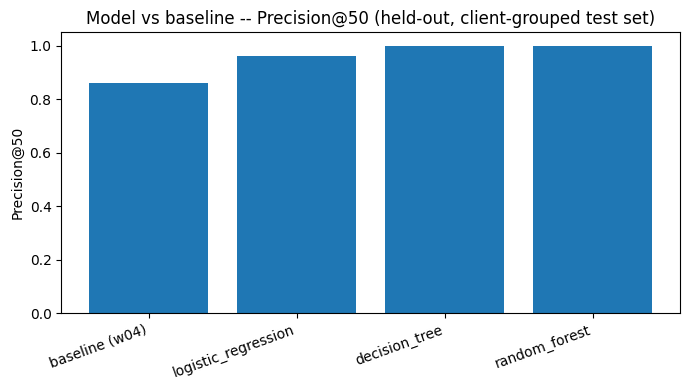

Artifacts saved: precision_at_50.png, results_table.csv, ranked_action_queue_top50.csv


In [10]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(results_df['model'], results_df['precision_at_50'])
ax.set_ylabel('Precision@50')
ax.set_title('Model vs baseline -- Precision@50 (held-out, client-grouped test set)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('precision_at_50.png', dpi=150)
plt.show()

results_df.to_csv('results_table.csv', index=False)
print('Artifacts saved: precision_at_50.png, results_table.csv, ranked_action_queue_top50.csv')


## ML-12 — Communicating the work

**5-minute demo outline**
1. (0:00-0:30) Le probleme : une requete split son trafic entre plusieurs pages du meme client.
2. (0:30-1:30) La donnee et le label : `is_cannibalized`, echelle (1,1M paires (client, query), 43 clients).
3. (1:30-2:30) Le piege leakage evite : split groupe par client, pourquoi c'etait necessaire.
4. (2:30-3:30) Le tableau Results : modeles vs baseline, et pourquoi Precision@50=1.00 n'est
   pas une victoire simple (feature dominante quasi-mecanique).
5. (3:30-4:30) La file d'action prioritaire (recommandations) -- a quoi ca sert concretement
   pour une equipe contenu.
6. (4:30-5:00) Limites + prochaine iteration (signal independant, validation multi-mois).

**Coupe reseau social (1 post, ton factuel)**

> On a construit un detecteur de cannibalisation de requetes sur 1,1M paires (client, query).
> Un decision tree honnete bat une heuristique simple (AUC 0.99 vs 0.94), mais 91% de son
> pouvoir vient d'une seule feature presque mecanique -- la vraie lecon : un score parfait
> merite d'etre questionne, pas celebre. Repo + paper en lien.

**Resume 3 phrases (destine a un recruteur/employeur)**

J'ai construit et valide un modele de detection de cannibalisation de requetes sur des
donnees de recherche reelles (1,1M lignes, 43 clients), avec un split groupe par client pour
eviter toute fuite de donnees. Le modele final depasse une heuristique de reference (AUC 0.99
vs 0.94) tout en identifiant honnetement sa propre limite principale -- une dependance forte a
une seule feature -- plutot que de presenter un score parfait sans nuance. Le livrable inclut
un paper de recherche public, un repo reproductible, et une file d'action prioritaire prete a
l'usage pour une equipe contenu.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
